[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JaimeHuaytallaPariona/ingenieria-conocimiento-uncp/blob/master/recursos/sesion_01_ciclo_vida_ml.ipynb)

# Sesión 01 — Ciclo de Vida de Proyectos de Machine Learning
**Curso:** Ingeniería del Conocimiento (ISO56B)  
**Docente:** Msc. Jaime Antonio Huaytalla Pariona  
**Periodo:** 2026-II | Universidad Nacional del Centro del Perú  

---

## Objetivo
Recorrer el ciclo de vida completo de un proyecto de Machine Learning — desde la recolección de datos hasta la evaluación y serialización del modelo — utilizando el dataset **Heart Disease** de UCI y las herramientas del ecosistema Scikit-learn.

## 1. Configuración del entorno
Instalamos/importamos las librerías necesarias. En Google Colab la mayoría ya están disponibles.

In [3]:
# Librerías principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)
import joblib

# Configuración visual
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('Entorno configurado correctamente.')

Entorno configurado correctamente.


---
## 2. Etapa 1 — Recolección de datos
🔧 **[Ej.2]** A diferencia de la sesión original (Heart Disease descargado por URL), aquí uso un dataset **propio y sin URL pública**: el ranking Top-200 de Clanes Globales de *Brawl Stars* (Kaggle, snapshot de septiembre 2023), que me llegó como archivo `.zip`. De ahí extraje `global_club_info.csv` y construí variables agregadas a partir de los hasta 30 miembros que tiene cada clan (cada miembro trae sus propios trofeos, rol, etc., así que los resumí en estadísticas por clan).

| Variable | Descripción |
|---|---|
| `requiredTrophies` | Trofeos mínimos exigidos para poder unirse al clan |
| `trophies` | Trofeos totales acumulados por el clan |
| `memberCount` | Número de miembros activos del clan (máximo 30) |
| `avgMemberTrophies` | Promedio de trofeos entre los miembros del clan |
| `stdMemberTrophies` | Desviación estándar de trofeos entre miembros (qué tan parejo es el clan) |
| `maxMemberTrophies` | Trofeos del miembro con más trofeos |
| `minMemberTrophies` | Trofeos del miembro con menos trofeos |
| `target` | Tipo de clan: 1 = `inviteOnly` (solo por invitación), 0 = `closed` (cerrado) |

In [9]:
DATA_PATH = 'global_club_info.csv'


try:
    raw = pd.read_csv(DATA_PATH, index_col=0)
    print(f'Dataset cargado desde archivo local — {raw.shape[0]} registros, {raw.shape[1]} columnas')
except FileNotFoundError as e:
    print(f'Error al cargar el archivo local: {e}')
    print('Sube "global_club_info.csv" a la misma carpeta que este notebook.')
    raise

member_trophy_cols = [c for c in raw.columns if c.startswith('member_') and c.endswith('_trophies')]

raw['memberCount']       = raw[member_trophy_cols].notna().sum(axis=1)
raw['avgMemberTrophies'] = raw[member_trophy_cols].mean(axis=1)
raw['stdMemberTrophies'] = raw[member_trophy_cols].std(axis=1).fillna(0)
raw['maxMemberTrophies'] = raw[member_trophy_cols].max(axis=1)
raw['minMemberTrophies'] = raw[member_trophy_cols].min(axis=1)

raw = raw[raw['type'] != 'open'].reset_index(drop=True)

raw['target'] = (raw['type'] == 'inviteOnly').astype(int)

feature_cols = ['requiredTrophies', 'trophies', 'memberCount',
                 'avgMemberTrophies', 'stdMemberTrophies',
                 'maxMemberTrophies', 'minMemberTrophies']

df = raw[feature_cols + ['target']].copy()
print(f'Dataset final para modelado — {df.shape[0]} registros, {df.shape[1]} columnas')
df.head()

Dataset cargado desde archivo local — 200 registros, 126 columnas
Dataset final para modelado — 199 registros, 8 columnas


,requiredTrophies,trophies,memberCount,avgMemberTrophies,stdMemberTrophies,maxMemberTrophies,minMemberTrophies,target
0,35000,2210359,30,73678.633333,7612.188862,85540.0,50470.0,0
1,35000,2196794,30,73226.466667,4792.398167,83660.0,59503.0,1
2,35000,2188358,29,75460.620690,4599.544033,88800.0,64882.0,1
3,35000,2157846,30,71928.200000,9402.803641,85559.0,29259.0,1
4,35000,2062393,30,68746.433333,5260.137632,79711.0,60316.0,1


---
## 3. Etapa 2 — Exploración y preparación de datos

In [10]:
# 3.1  Información general del dataset
print('='*60)
print('INFORMACIÓN DEL DATASET')
print('='*60)
df.info()
print('\n')
df.describe().round(2)

INFORMACIÓN DEL DATASET
<class 'pandas.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   requiredTrophies   199 non-null    int64  
 1   trophies           199 non-null    int64  
 2   memberCount        199 non-null    int64  
 3   avgMemberTrophies  199 non-null    float64
 4   stdMemberTrophies  199 non-null    float64
 5   maxMemberTrophies  199 non-null    float64
 6   minMemberTrophies  199 non-null    float64
 7   target             199 non-null    int64  
dtypes: float64(4), int64(4)
memory usage: 12.6 KB




,requiredTrophies,trophies,memberCount,avgMemberTrophies,stdMemberTrophies,maxMemberTrophies,minMemberTrophies,target
count,199.00,199.00,199.00,199.00,199.00,199.00,199.00,199.00
mean,33216.08,1788958.59,29.75,60158.74,5643.38,71925.14,45918.86,0.84
std,7667.89,100908.59,0.57,3607.23,2727.27,6770.15,10946.59,0.36
min,0.00,1654596.00,27.00,56399.87,1926.38,61474.00,3212.00,0.00
25%,35000.00,1716173.50,30.00,57485.53,3688.06,66386.00,41315.50,1.00
50%,35000.00,1757754.00,30.00,59192.73,4973.48,70364.00,49903.00,1.00
75%,35000.00,1827284.50,30.00,61335.65,6870.13,75338.50,52515.50,1.00
max,35000.00,2210359.00,30.00,75460.62,18934.56,90807.00,64882.00,1.00


In [11]:
# 3.2  Verificación de valores nulos y duplicados
print('Valores nulos por columna:')
print(df.isnull().sum())
print(f'\nRegistros duplicados: {df.duplicated().sum()}')

# Eliminar duplicados si existen
df = df.drop_duplicates().reset_index(drop=True)
print(f'Registros después de limpieza: {df.shape[0]}')

Valores nulos por columna:
requiredTrophies     0
trophies             0
memberCount          0
avgMemberTrophies    0
stdMemberTrophies    0
maxMemberTrophies    0
minMemberTrophies    0
target               0
dtype: int64

Registros duplicados: 0
Registros después de limpieza: 199


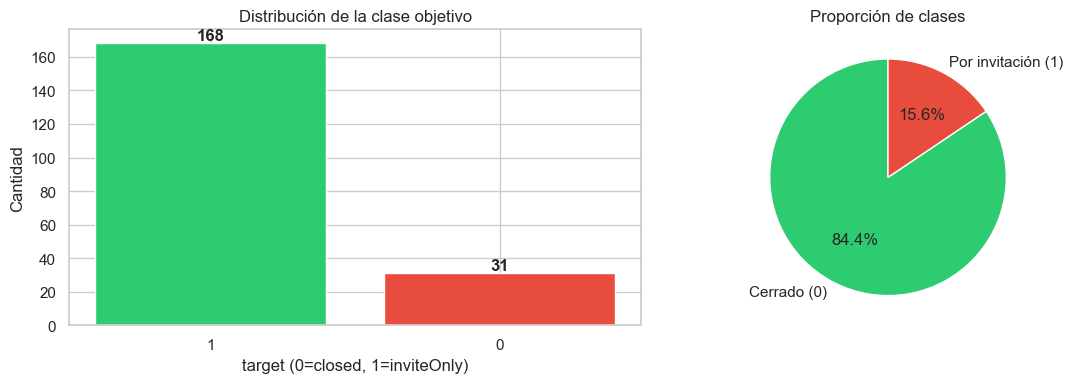

In [12]:
# 3.3  Distribución de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Conteo
target_counts = df['target'].value_counts()
axes[0].bar(target_counts.index.astype(str), target_counts.values,
            color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribución de la clase objetivo')
axes[0].set_xlabel('target (0=closed, 1=inviteOnly)')  # 🔧 [Ej.2] nuevas categorías
axes[0].set_ylabel('Cantidad')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Proporción
axes[1].pie(target_counts.values, labels=['Cerrado (0)', 'Por invitación (1)'],  # 🔧 [Ej.2]
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Proporción de clases')

plt.tight_layout()
plt.show()

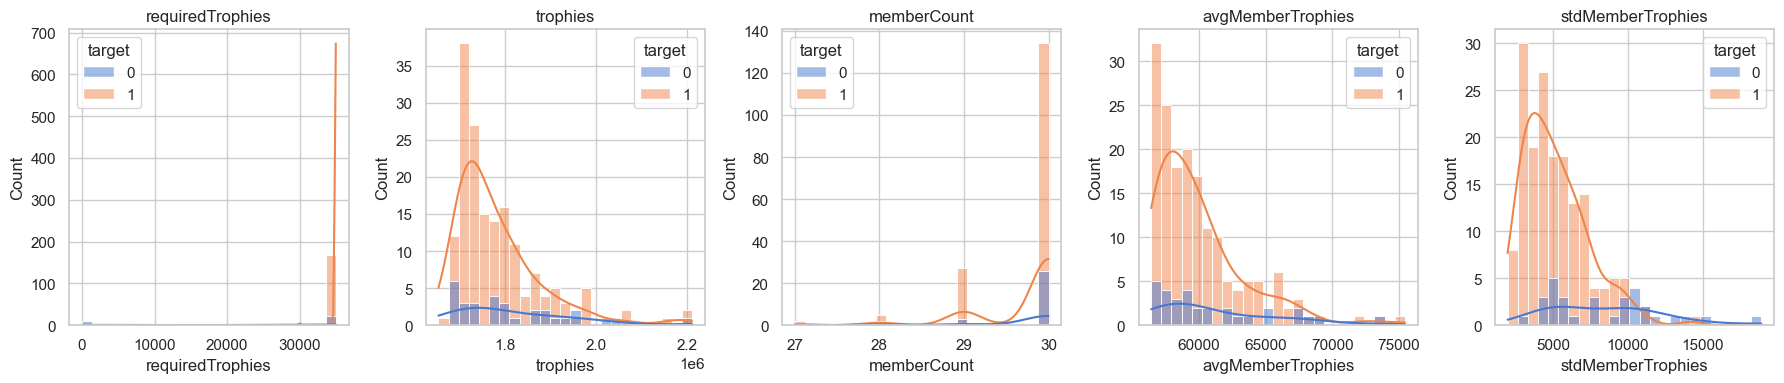

In [13]:

num_cols = ['requiredTrophies', 'trophies', 'memberCount', 'avgMemberTrophies', 'stdMemberTrophies']

fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(data=df, x=col, hue='target', kde=True, ax=ax, bins=25)
    ax.set_title(col)
plt.tight_layout()
plt.show()

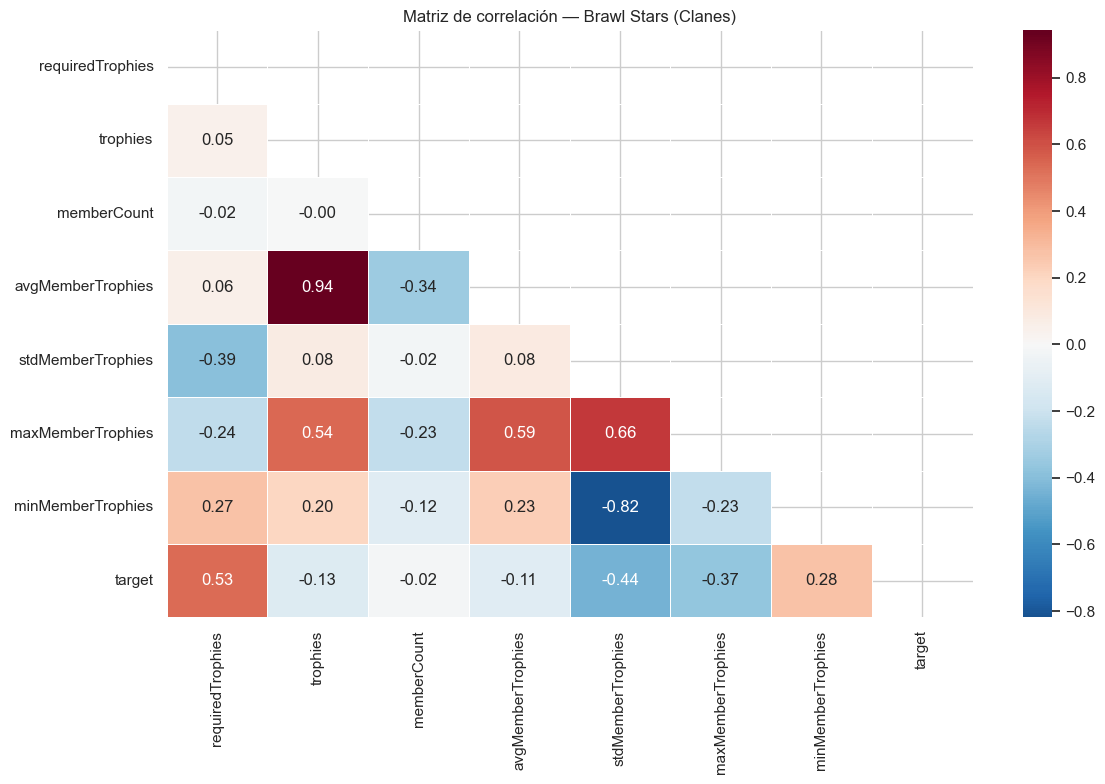

In [14]:

plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5)
plt.title('Matriz de correlación — Brawl Stars (Clanes)')  # 🔧 [Ej.2]
plt.tight_layout()
plt.show()

---
## 4. Etapa 3 — Preparación de datos para el modelado

In [15]:

X = df.drop(columns='target')
y = df['target']

print(f'Features: {X.shape}')   # (n_samples, n_features)
print(f'Target:   {y.shape}')   # (n_samples,)

Features: (199, 7)
Target:   (199,)


In [16]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} muestras')
print(f'Test:  {X_test.shape[0]} muestras')
print(f'\nProporción target en train:\n{y_train.value_counts(normalize=True).round(3)}')
print(f'\nProporción target en test:\n{y_test.value_counts(normalize=True).round(3)}')

Train: 159 muestras
Test:  40 muestras

Proporción target en train:
target
1    0.843
0    0.157
Name: proportion, dtype: float64

Proporción target en test:
target
1    0.85
0    0.15
Name: proportion, dtype: float64


---
## 5. Etapa 4 — Entrenamiento de modelos
Entrenamos tres modelos base mediante **pipelines** de Scikit-learn para garantizar un flujo reproducible.

In [17]:
# 5.1  Definición de pipelines
pipelines = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'DecisionTree': Pipeline([
        ('clf', DecisionTreeClassifier(max_depth=5, random_state=42))
    ]),
    'RandomForest': Pipeline([
        ('clf', RandomForestClassifier(n_estimators=200, max_depth=7, random_state=42))
    ])
}

results = {}
for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy')
    results[name] = scores
    print(f'{name:25s}  Accuracy CV: {scores.mean():.4f} ± {scores.std():.4f}')

LogisticRegression         Accuracy CV: 0.8800 ± 0.0517
DecisionTree               Accuracy CV: 0.8419 ± 0.0690
RandomForest               Accuracy CV: 0.8609 ± 0.0611


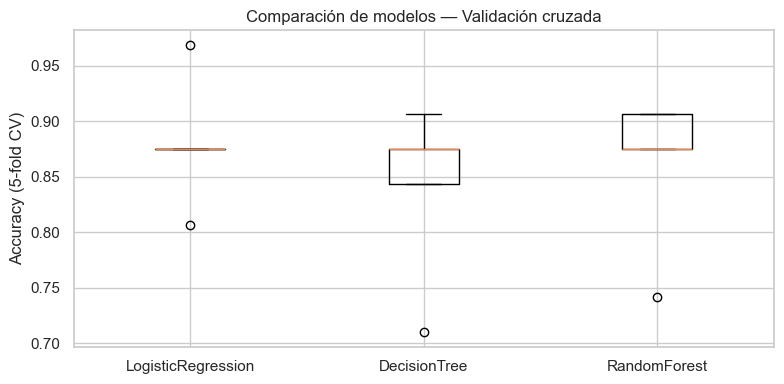

In [18]:

fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(results.values(), tick_labels=results.keys())
ax.set_ylabel('Accuracy (5-fold CV)')
ax.set_title('Comparación de modelos — Validación cruzada')
plt.tight_layout()
plt.show()

---
## 6. Etapa 5 — Evaluación del mejor modelo

In [19]:

best_name = max(results, key=lambda k: results[k].mean())
best_pipeline = pipelines[best_name]
best_pipeline.fit(X_train, y_train)

y_pred = best_pipeline.predict(X_test)

print(f'Mejor modelo: {best_name}')
print(f'Accuracy en test: {best_pipeline.score(X_test, y_test):.4f}')
print('\n' + '='*60)
print('CLASSIFICATION REPORT')
print('='*60)
print(classification_report(y_test, y_pred, target_names=['Cerrado', 'Por invitación']))  # 🔧 [Ej.2]

Mejor modelo: LogisticRegression
Accuracy en test: 0.8750

CLASSIFICATION REPORT
                precision    recall  f1-score   support

       Cerrado       1.00      0.17      0.29         6
Por invitación       0.87      1.00      0.93        34

      accuracy                           0.88        40
     macro avg       0.94      0.58      0.61        40
  weighted avg       0.89      0.88      0.83        40



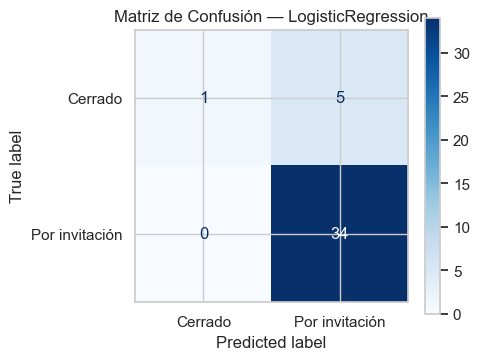

In [20]:

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Cerrado', 'Por invitación'],  # 🔧 [Ej.2]
    cmap='Blues', ax=ax
)
ax.set_title(f'Matriz de Confusión — {best_name}')
plt.tight_layout()
plt.show()

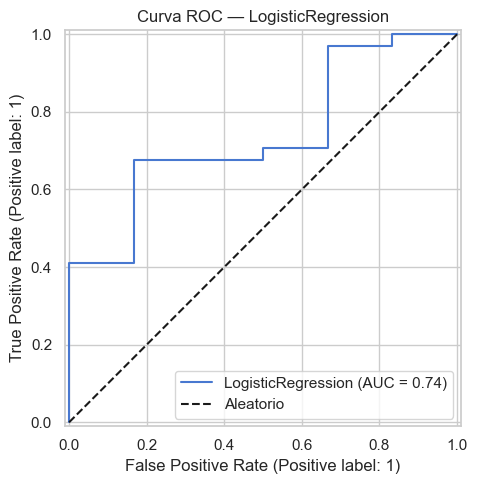

In [21]:

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(best_pipeline, X_test, y_test, ax=ax, name=best_name)
ax.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
ax.set_title(f'Curva ROC — {best_name}')
ax.legend()
plt.tight_layout()
plt.show()

 Con este dataset el `classification_report` me dio un resultado que no esperaba: el recall de la clase `Cerrado` es muy bajo (0.17), mientras que `Por invitación` sale casi perfecto. Investigando un poco, es el mismo problema de desbalance de clases que se menciona en la teoría del curso: de 199 clanes, 168 son `inviteOnly` (84%) y solo 31 son `closed` (16%). El accuracy general (0.88) se ve "bien" pero esconde que el modelo casi no está aprendiendo a distinguir la clase minoritaria — apenas un poco mejor que si predijera `inviteOnly` siempre. Para un trabajo real habría que probar `class_weight='balanced'`, oversampling (SMOTE) o mirar métricas como el F1 macro en vez de solo el accuracy.

---
## 7. Etapa 6 — Serialización y despliegue conceptual
Guardamos el pipeline entrenado con `joblib` para simular la etapa de despliegue.

In [22]:
# 7.1  Guardar el modelo
MODEL_PATH = 'club_type_model.joblib'  
joblib.dump(best_pipeline, MODEL_PATH)
print(f'Modelo guardado en: {MODEL_PATH}')

Modelo guardado en: club_type_model.joblib


In [23]:
# 7.2  Cargar y verificar el modelo serializado
loaded_model = joblib.load(MODEL_PATH)

# Verificación rápida: misma predicción con datos de test
assert np.array_equal(loaded_model.predict(X_test), y_pred), 'Error: predicciones no coinciden'
print('Verificación OK: el modelo cargado reproduce las predicciones.')

Verificación OK: el modelo cargado reproduce las predicciones.


In [24]:

def predict_club_type(club_data: dict) -> dict:
    """
    Recibe un diccionario con las estadísticas agregadas de un clan
    y retorna la predicción (closed / inviteOnly) junto con la probabilidad.
    """
    model = joblib.load(MODEL_PATH)

    input_df = pd.DataFrame([[club_data[col] for col in feature_cols]], columns=feature_cols)

    pred = model.predict(input_df)[0]
    proba = model.predict_proba(input_df)[0]

    prediction_label = 'Por invitación (inviteOnly)' if pred == 1 else 'Cerrado (closed)'

    return {
        'prediccion': prediction_label,
        'probabilidad_inviteOnly': round(float(proba[1]), 4),
        'probabilidad_closed': round(float(proba[0]), 4)
    }

clan_ejemplo = {
    'requiredTrophies': 30000,
    'trophies': 1800000,
    'memberCount': 30,
    'avgMemberTrophies': 60000,
    'stdMemberTrophies': 4000,
    'maxMemberTrophies': 75000,
    'minMemberTrophies': 50000
}

resultado = predict_club_type(clan_ejemplo)
print('\n--- Resultado de inferencia ---')
for k, v in resultado.items():
    print(f'  {k}: {v}')


--- Resultado de inferencia ---
  prediccion: Por invitación (inviteOnly)
  probabilidad_inviteOnly: 0.8325
  probabilidad_closed: 0.1675


---
## 8. Resumen del ciclo de vida recorrido

| Etapa | Qué hicimos | Herramientas |
|---|---|---|
| **Recolección** | Carga local del dataset Brawl Stars (Clanes) + ingeniería de variables agregadas | `pandas` (sin URL — archivo local) 🔧[Ej.2] |
| **Exploración** | Análisis de distribuciones, correlaciones, nulos | `seaborn`, `matplotlib` |
| **Preparación** | Limpieza, split estratificado 80/20 | `train_test_split` |
| **Entrenamiento** | 3 modelos con pipelines + validación cruzada 5-fold | `Pipeline`, `cross_val_score` |
| **Evaluación** | Accuracy, precision, recall, F1, ROC, matriz confusión | `classification_report`, `RocCurveDisplay` |
| **Despliegue** | Serialización con joblib + función de inferencia | `joblib` |

---
## 9. Ejercicios propuestos

### Ejercicio 1 — Experimentación con hiperparámetros
Utilice `GridSearchCV` o `RandomizedSearchCV` para optimizar los hiperparámetros del `RandomForestClassifier`. Compare el accuracy antes y después del tuning.

### Ejercicio 2 — Nuevo dataset, mismo pipeline
Descargue el dataset **Diabetes** de Scikit-learn (`sklearn.datasets.load_diabetes`) o el **Breast Cancer Wisconsin** (`sklearn.datasets.load_breast_cancer`) y replique el ciclo de vida completo aplicado en esta sesión.

### Ejercicio 3 — Registro de experimentos
Investigue la librería **MLflow** (`!pip install mlflow`) e implemente un registro básico de las métricas y parámetros de cada modelo entrenado. Documente los pasos realizados.

---
## 10. Solución Ejercicio 3 — Registro de experimentos con MLflow

Para este ejercicio investigué la librería **[MLflow](https://mlflow.org/)**. En corto: permite registrar cada corrida de entrenamiento (un "run") con sus parámetros, métricas y hasta el modelo serializado como artefacto, para poder comparar experimentos después sin tener que volver a correr todo ni anotar resultados a mano en otro lado.

Lo que hago acá es reutilizar los `pipelines` y `results` que ya calculé en la Etapa 4 (validación cruzada) y el `best_pipeline` de la Etapa 5, y los registro en MLflow en vez de solo imprimirlos por pantalla.

In [25]:
# 10.1  Instalación e importación
!pip install mlflow -q

import mlflow
import mlflow.sklearn

# MLflow guarda los experimentos localmente en una carpeta ./mlruns
# (una especie de "base de datos" de corridas, sin necesitar un servidor aparte)
mlflow.set_experiment('brawl_stars_club_type_classification')
print('Experimento configurado:', mlflow.get_experiment_by_name('brawl_stars_club_type_classification').name)

Experimento configurado: brawl_stars_club_type_classification


In [26]:
# 10.2  Un "run" de MLflow por cada modelo probado en la Etapa 4
# (reutilizo pipelines y results, no vuelvo a hacer cross_val_score)
model_params = {
    'LogisticRegression': {'max_iter': 1000},
    'DecisionTree': {'max_depth': 5},
    'RandomForest': {'n_estimators': 200, 'max_depth': 7}
}

for name, pipe in pipelines.items():
    with mlflow.start_run(run_name=name):
        mlflow.log_param('modelo', name)
        for param_name, param_value in model_params[name].items():
            mlflow.log_param(param_name, param_value)

        mlflow.log_metric('cv_accuracy_mean', results[name].mean())
        mlflow.log_metric('cv_accuracy_std', results[name].std())

        pipe.fit(X_train, y_train)
        # Uso serialization_format='cloudpickle': la opción por defecto ('skops')
        # me tiró un error de "tipos no confiables" al guardar el RandomForest/DecisionTree
        # en esta versión de MLflow. Como el modelo es mío y confío en su origen, cloudpickle
        # es suficiente para este ejercicio académico.
        mlflow.sklearn.log_model(pipe, name='model', serialization_format='cloudpickle')

        print(f'Run registrado -> {name}: CV accuracy = {results[name].mean():.4f}')

2026/09/18 01:52:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/09/18 01:52:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run registrado -> LogisticRegression: CV accuracy = 0.8800
Run registrado -> DecisionTree: CV accuracy = 0.8419


2026/09/18 01:52:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run registrado -> RandomForest: CV accuracy = 0.8609


In [27]:
# 10.3  Un run adicional con las métricas finales del mejor modelo (Etapa 5)
with mlflow.start_run(run_name=f'{best_name}_final_test'):
    mlflow.log_param('modelo', best_name)
    mlflow.log_metric('test_accuracy', best_pipeline.score(X_test, y_test))

    report_dict = classification_report(
        y_test, y_pred, target_names=['Cerrado', 'Por invitación'], output_dict=True
    )
    mlflow.log_metric('precision_inviteOnly', report_dict['Por invitación']['precision'])
    mlflow.log_metric('recall_inviteOnly', report_dict['Por invitación']['recall'])
    mlflow.log_metric('f1_inviteOnly', report_dict['Por invitación']['f1-score'])

    mlflow.sklearn.log_model(best_pipeline, name='best_model', serialization_format='cloudpickle')
    mlflow.log_artifact(MODEL_PATH)  # también el .joblib que generé en la Etapa 6

print('Run final del mejor modelo registrado en MLflow.')

2026/09/18 01:52:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run final del mejor modelo registrado en MLflow.


In [28]:
# 10.4  Consultar el historial de experimentos desde el propio notebook
# (en local/Colab con terminal también se puede correr `!mlflow ui` y abrir
# la URL que muestra, para ver todo esto en una interfaz web)
runs_df = mlflow.search_runs(experiment_names=['brawl_stars_club_type_classification'])
runs_df[['run_id', 'tags.mlflow.runName', 'params.modelo',
         'metrics.cv_accuracy_mean', 'metrics.test_accuracy']]

,run_id,tags.mlflow.runName,params.modelo,metrics.cv_accuracy_mean,metrics.test_accuracy
0,3fa1337afd874a1497ba38be04003447,LogisticRegression_final_test,LogisticRegression,NaN,0.875
1,765581644fac44bc8e8a59be79816971,RandomForest,RandomForest,0.860887,NaN
2,b9502017342245ad9c93ea95ed0b0c9a,DecisionTree,DecisionTree,0.841935,NaN
3,4cf263cb8ec24eef94e5c6c445894496,LogisticRegression,LogisticRegression,0.880040,NaN
